# Bước 1: Khám phá Dữ liệu (EDA) và Tiền xử lý
Notebook này đóng vai trò như bản báo cáo chi tiết từng bước trong quá trình chuẩn bị dữ liệu. Ở mỗi bước, chúng ta không chỉ code mà còn hiểu rõ **"Tại sao phải làm như vậy?"**

## 1. Import Thư viện cần thiết
**Ý nghĩa của bước này:**
- `cv2` (OpenCV): Thư viện chuyên dụng để đọc và biến đổi hình ảnh (thay đổi kích thước, đổi không gian màu).
- `numpy`: AI không hiểu hình ảnh, nó chỉ hiểu ma trận số. Numpy giúp ta xử lý các ma trận này.
- `matplotlib` & `seaborn`: Dùng để vẽ các biểu đồ báo cáo trực quan, đẹp mắt và dễ hiểu.

In [171]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Thiết lập font và style cho biểu đồ
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

DATASET_PATH = "../dataset/train"
classes = [d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))]
classes.sort()
print("Các nhãn (classes) trong dataset:", classes)

Các nhãn (classes) trong dataset: ['cardboard', 'glass', 'metal', 'organic', 'paper', 'plastic', 'trash']


## 2. Trực quan và Phân tích Dữ liệu (EDA)
### 2.1. Phân phối số lượng mẫu dữ liệu (Class Distribution)
**Ý nghĩa của bước này:**
Trước khi huấn luyện, ta bắt buộc phải đếm xem mỗi loại rác có bao nhiêu bức ảnh. Nếu một loại rác (VD: giấy) có tới 5000 ảnh, trong khi rác kim loại chỉ có 100 ảnh, mô hình sẽ bị "thiên vị" (Imbalanced Data) và luôn có xu hướng đoán là giấy. Việc vẽ biểu đồ cột giúp ta kiểm tra độ cân bằng của dữ liệu ngay từ đầu.

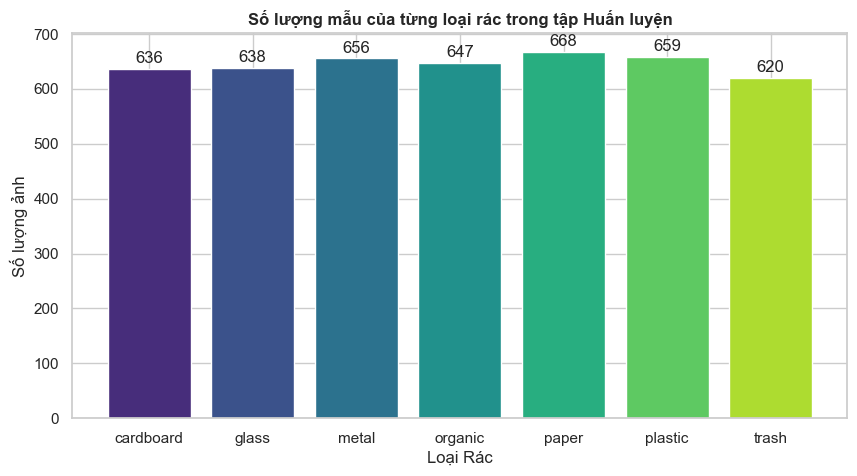

In [173]:
class_counts = []
for c in classes:
    count = len(os.listdir(os.path.join(DATASET_PATH, c)))
    class_counts.append(count)

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))
bars = plt.bar(classes, class_counts, color=sns.color_palette("viridis", len(classes)))
plt.title('Số lượng mẫu của từng loại rác trong tập Huấn luyện', fontweight='bold')
plt.xlabel('Loại Rác')
plt.ylabel('Số lượng ảnh')

# Hiển thị số lượng trên đỉnh cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')

plt.show()

### 2.2. Trực quan hóa dữ liệu gốc (Sanity Check)
**Ý nghĩa của bước này:**
Không thể nhắm mắt tin tưởng hoàn toàn vào nguồn dữ liệu tải trên mạng. Việc in ngẫu nhiên vài bức ảnh ra màn hình là bước "kiểm tra bằng mắt thường" (Sanity Check) để đảm bảo hình ảnh không bị lỗi hỏng, đúng nhãn (không có chuyện thư mục `plastic` nhưng lại chứa ảnh chó mèo).

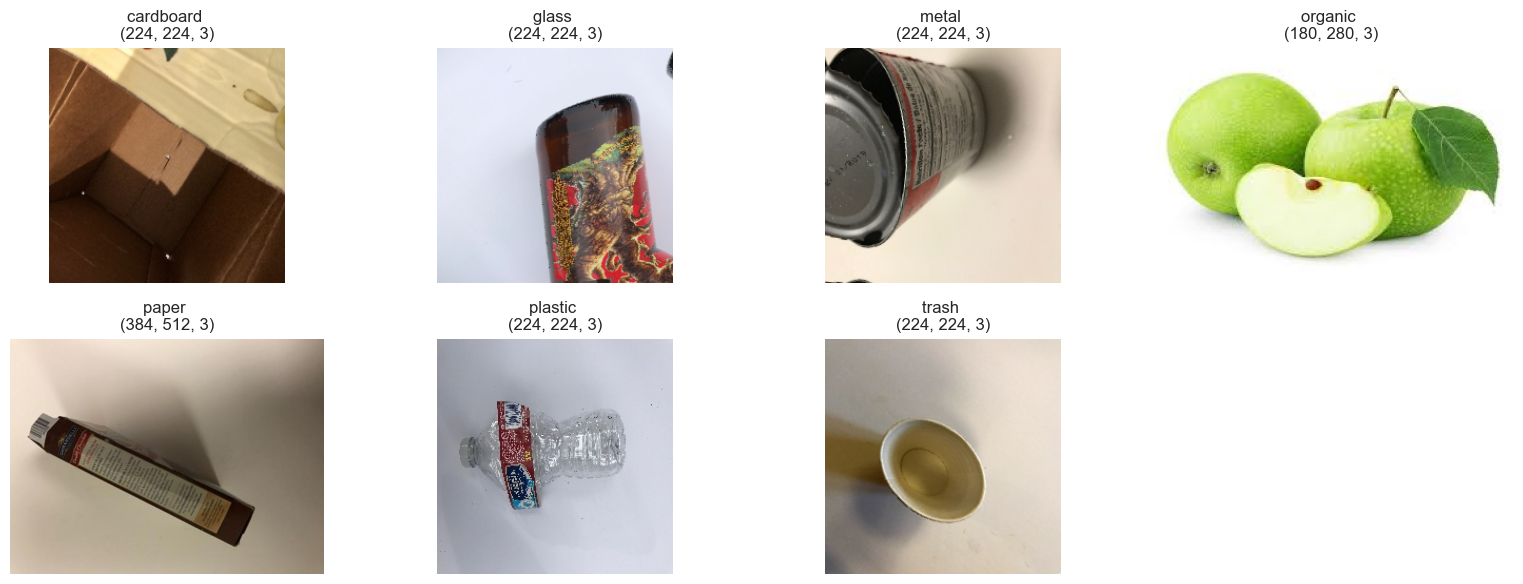

In [175]:
plt.figure(figsize=(16, 6))
for i, cls in enumerate(classes):
    cls_path = os.path.join(DATASET_PATH, cls)
    images = [f for f in os.listdir(cls_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
    if not images: continue
        
    img_path = os.path.join(cls_path, random.choice(images))
    
    # OpenCV đọc ảnh theo hệ BGR, ta cần chuyển sang RGB để plt hiển thị đúng màu
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2, 4, i + 1)
    plt.imshow(img_rgb)
    plt.title(f"{cls} \n{img_rgb.shape}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## 3. Tiền xử lý (Preprocessing) & Trích xuất Đặc trưng
**Tư duy thuật toán:**
Máy tính (như mô hình SVM, KNN) KHÔNG nhìn được bức ảnh như con người. Nó chỉ hiểu một mảng các con số (Vector 1 chiều). Nhiệm vụ của Tiền xử lý là phải trích xuất ra các "đặc điểm" nổi bật nhất của bức ảnh (màu sắc, hình khối) và biến chúng thành các con số toán học.

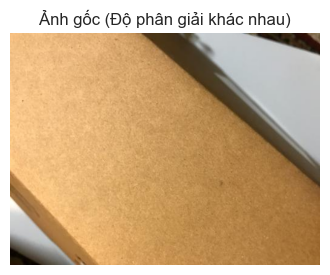

In [177]:
# Lấy 1 ảnh bất kỳ làm ví dụ
sample_class = classes[0]
sample_files = os.listdir(os.path.join(DATASET_PATH, sample_class))
sample_img_path = os.path.join(DATASET_PATH, sample_class, sample_files[0])

# 1. Đọc và chuyển đổi màu RGB
raw_img = cv2.imread(sample_img_path)
img_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4, 4))
plt.imshow(img_rgb)
plt.title("Ảnh gốc (Độ phân giải khác nhau)")
plt.axis('off')
plt.show()

### Bước 3.1. Đưa về kích thước chuẩn (Resize)
**Ý nghĩa của bước này:**
Ảnh trong thực tế có kích thước lộn xộn (4K, Full HD, ảnh vuông, ảnh dọc). Ta bắt buộc phải ép tất cả ảnh về chung một kích thước (ví dụ `64x64`) thì thuật toán mới nhận đầu vào có cùng số lượng chiều (dimension) được.

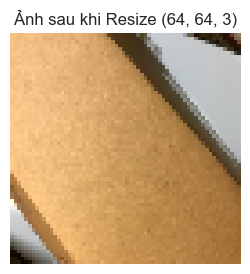

In [179]:
img_resized = cv2.resize(img_rgb, (64, 64))

plt.figure(figsize=(3, 3))
plt.imshow(img_resized)
plt.title(f"Ảnh sau khi Resize {img_resized.shape}")
plt.axis('off')
plt.show()

### Bước 3.2. Trích xuất đặc trưng Cấu trúc (Small Pixels)
**Ý nghĩa của bước này:**
Làm sao để máy tính biết rác nilon thường nhàu nhĩ, còn bìa carton thường vuông vức? Chúng ta ép bức ảnh `64x64` thu nhỏ lại thành lưới cực nhỏ `8x8`. Thao tác này có ý nghĩa cực lớn: Nó làm mờ đi các chi tiết chữ viết, hoa văn thừa thãi, chỉ giữ lại ĐƯỜNG NÉT TỔNG QUAN của rác. Sau đó ta trải phẳng lưới 8x8 thành một mảng 64 số (từ 0-1).

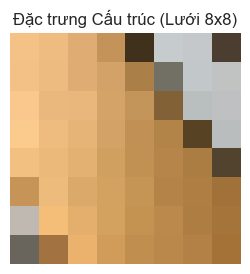

Vector cấu trúc có độ dài: 192 chiều


In [181]:
small_img = cv2.resize(img_resized, (8, 8))
small_features = small_img.flatten() / 255.0  # Chuẩn hóa về [0, 1]

plt.figure(figsize=(3, 3))
plt.imshow(small_img)
plt.title("Đặc trưng Cấu trúc (Lưới 8x8)")
plt.axis('off')
plt.show()

print(f"Vector cấu trúc có độ dài: {len(small_features)} chiều")

### Bước 3.3. Trích xuất Đặc trưng Màu sắc (HSV Histogram)
**Ý nghĩa của bước này:**
Rác hữu cơ thường có màu xanh lục/nâu, thủy tinh thường có xanh lam. Màu sắc là chìa khóa phân loại. Tuy nhiên, thay vì dùng hệ màu RGB (Red Green Blue) rất dễ bị ảnh hưởng bởi ánh sáng môi trường (sáng sớm hay chiều tối), ta chuyển ảnh sang **hệ màu HSV**. HSV bóc tách riêng biệt "Độ sáng" ra khỏi "Màu sắc gốc", giúp chống nhiễu ánh sáng cực tốt. Sau đó ta đếm tần suất xuất hiện của các dải màu tạo thành 3 biểu đồ (Histogram).

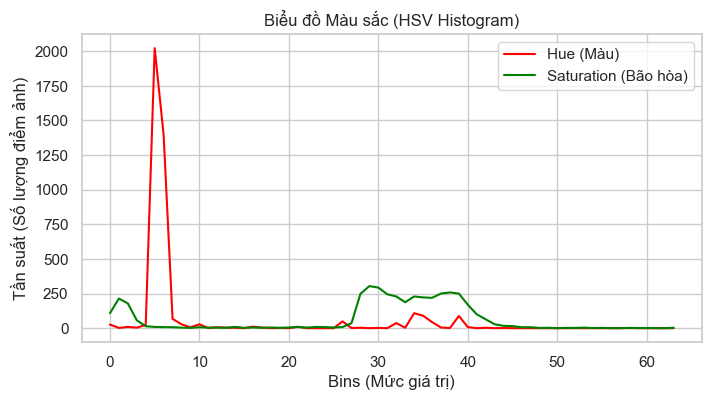

Vector màu sắc có độ dài: 192 chiều


In [183]:
hsv = cv2.cvtColor(img_resized, cv2.COLOR_RGB2HSV)

# Tính Histogram cho kênh Hue (Màu sắc), Saturation (Độ bão hòa), Value (Độ sáng)
# Sử dụng 64 bins để có độ chi tiết cao
h_hist = cv2.calcHist([hsv], [0], None, [64], [0, 180])
s_hist = cv2.calcHist([hsv], [1], None, [64], [0, 256])
v_hist = cv2.calcHist([hsv], [2], None, [64], [0, 256])

# Vẽ biểu đồ Màu sắc (Hue)
plt.figure(figsize=(8, 4))
plt.plot(h_hist, color='red', label='Hue (Màu)')
plt.plot(s_hist, color='green', label='Saturation (Bão hòa)')
plt.title("Biểu đồ Màu sắc (HSV Histogram)")
plt.xlabel("Bins (Mức giá trị)")
plt.ylabel("Tần suất (Số lượng điểm ảnh)")
plt.legend()
plt.show()

# Nối 3 biểu đồ lại thành 1 vector duy nhất
color_features = np.concatenate([h_hist, s_hist, v_hist]).flatten()
cv2.normalize(color_features, color_features)
print(f"Vector màu sắc có độ dài: {len(color_features)} chiều")

### Bước 3.4. Ghép Đặc trưng & Chuẩn hóa (Standardization)
**Ý nghĩa của bước này:**
Ghép 2 vector (Cấu trúc + Màu sắc) lại thành 1. Tuy nhiên, các đặc trưng đang có thang đo "lệch pha" nhau (có cái thì giá trị bé xíu từ 0-1, có cái lại là số lượng điểm ảnh to đùng hàng trăm). Nếu ném thẳng vào mô hình SVM (vốn đo lường bằng khoảng cách toán học), số lớn sẽ "đè bẹp" số nhỏ, làm AI bị sai lệch trầm trọng.

**Giải pháp:** Áp dụng `StandardScaler` để ép toàn bộ dữ liệu về chung một hệ quy chiếu Công bằng (Trung bình $\mu=0$, Độ lệch chuẩn $\sigma=1$). Dưới đây là bằng chứng trực quan:

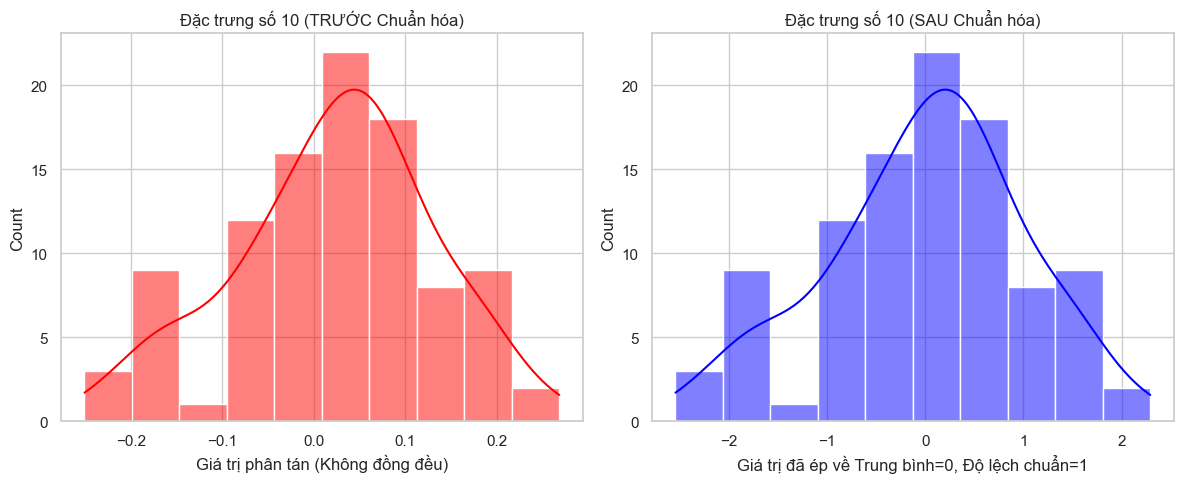

🎯 TỔNG KẾT BƯỚC 1: Mỗi bức ảnh khổng lồ nay đã được biểu diễn bởi một Vector 384 chiều toán học.
Quá trình Tiền xử lý hoàn tất! Dữ liệu đã SẠCH, CHUẨN và SẴN SÀNG để tiến vào Bước 2: Huấn luyện Mô hình.


In [185]:
from sklearn.preprocessing import StandardScaler

final_features = np.concatenate([color_features, small_features])

# Giả lập một tập dữ liệu gồm 100 bức ảnh (bằng cách thêm nhiễu ngẫu nhiên vào vector gốc)
X_dummy = np.array([final_features + np.random.normal(0, 0.1, len(final_features)) for _ in range(100)])

# Áp dụng StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_dummy)

# Trực quan hóa so sánh sự thay đổi của Đặc trưng số 10 (ví dụ)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(X_dummy[:, 10], kde=True, color='red')
plt.title("Đặc trưng số 10 (TRƯỚC Chuẩn hóa)")
plt.xlabel("Giá trị phân tán (Không đồng đều)")

plt.subplot(1, 2, 2)
sns.histplot(X_scaled[:, 10], kde=True, color='blue')
plt.title("Đặc trưng số 10 (SAU Chuẩn hóa)")
plt.xlabel("Giá trị đã ép về Trung bình=0, Độ lệch chuẩn=1")

plt.tight_layout()
plt.show()

print(f"🎯 TỔNG KẾT BƯỚC 1: Mỗi bức ảnh khổng lồ nay đã được biểu diễn bởi một Vector {len(final_features)} chiều toán học.")
print("Quá trình Tiền xử lý hoàn tất! Dữ liệu đã SẠCH, CHUẨN và SẴN SÀNG để tiến vào Bước 2: Huấn luyện Mô hình.")